In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**split  70-15-15**






In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

DATASET_DIR = "/content/drive/MyDrive/datasets/brain-tumor"

original_train_dir = os.path.join(DATASET_DIR, "Training")
original_test_dir  = os.path.join(DATASET_DIR, "Testing")


OUTPUT_DIR = "/content/drive/MyDrive/datasets/brain_tumor_70_15_15"

classes = sorted([
    cls for cls in os.listdir(original_train_dir)
    if os.path.isdir(os.path.join(original_train_dir, cls))
])

print("Classes:", classes)
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


for cls in classes:
    print(f"\nProcessing class: {cls}")

    train_cls_path = os.path.join(original_train_dir, cls)
    test_cls_path  = os.path.join(original_test_dir, cls)

    images = []

    if os.path.exists(train_cls_path):
        images += [
            os.path.join(train_cls_path, img)
            for img in os.listdir(train_cls_path)
            if img.lower().endswith(valid_exts)
        ]

    if os.path.exists(test_cls_path):
        images += [
            os.path.join(test_cls_path, img)
            for img in os.listdir(test_cls_path)
            if img.lower().endswith(valid_exts)
        ]

    print("Total images:", len(images))

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    def copy_images(image_list, split_name):
        for i, img_path in enumerate(image_list):
            filename = os.path.basename(img_path)

            # rename to avoid duplicate filenames
            new_filename = f"{cls}_{split_name}_{i}_{filename}"

            dst = os.path.join(OUTPUT_DIR, split_name, cls, new_filename)
            shutil.copy2(img_path, dst)

    copy_images(train_imgs, "train")
    copy_images(val_imgs, "val")
    copy_images(test_imgs, "test")

    print("Train:", len(train_imgs))
    print("Val:  ", len(val_imgs))
    print("Test: ", len(test_imgs))

print("\nDone splitting dataset.")
print("Saved to:", OUTPUT_DIR)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Processing class: glioma


KeyboardInterrupt: 

**Transforms**

In [7]:
from torchvision import transforms

IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Augmentation على التدريب فقط
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),

    # ResNet50 يحتاج 3 channels
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    # Normalization مناسب للموديلات pretrained على ImageNet
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**DataLoaders**

In [8]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

OUTPUT_DIR = "/content/drive/MyDrive/datasets/brain_tumor_70_15_15"

train_path = os.path.join(OUTPUT_DIR, "train")
val_path   = os.path.join(OUTPUT_DIR, "val")
test_path  = os.path.join(OUTPUT_DIR, "test")

BATCH_SIZE = 32

train_dataset = ImageFolder(train_path, transform=train_transforms)
val_dataset   = ImageFolder(val_path, transform=val_transforms)
test_dataset  = ImageFolder(test_path, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Class to idx:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to idx: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train size: 5049
Val size:   1082
Test size:  1082


In [9]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


ResNet50 Feature **Extractor**

In [10]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained ResNet50
weights = ResNet50_Weights.DEFAULT
feature_extractor = resnet50(weights=weights)

# Remove final classification layer
feature_extractor = torch.nn.Sequential(
    *list(feature_extractor.children())[:-1]
)

# Freeze model parameters
for param in feature_extractor.parameters():
    param.requires_grad = False

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet50 Feature Extractor Ready ✅")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 126MB/s]


ResNet50 Feature Extractor Ready ✅


** Extract Features train / val / test**

In [11]:
def extract_features(model, loader):
    all_features = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)

            outputs = model(images)

            # Shape: [batch, 2048, 1, 1] -> [batch, 2048]
            outputs = outputs.view(outputs.size(0), -1)

            all_features.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y


print("Extracting train features...")
X_train, y_train = extract_features(feature_extractor, train_loader)

print("Extracting validation features...")
X_val, y_val = extract_features(feature_extractor, val_loader)

print("Extracting test features...")
X_test, y_test = extract_features(feature_extractor, test_loader)

print("\nTrain Features Shape:", X_train.shape)
print("Val Features Shape:  ", X_val.shape)
print("Test Features Shape: ", X_test.shape)

Extracting train features...


100%|██████████| 158/158 [16:06<00:00,  6.11s/it]


Extracting validation features...


100%|██████████| 34/34 [05:03<00:00,  8.91s/it]


Extracting test features...


100%|██████████| 34/34 [04:56<00:00,  8.72s/it]


Train Features Shape: (5049, 2048)
Val Features Shape:   (1082, 2048)
Test Features Shape:  (1082, 2048)


**Linear SVM و Logistic Regression**

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# =========================
# Model 1: Linear SVM
# =========================
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=1.0,
        max_iter=10000,
        random_state=42
    )
)

# =========================
# Model 2: Logistic Regression
# =========================
log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        max_iter=3000,
        solver="saga",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
)

print("Training Linear SVM...")
svm_model.fit(X_train, y_train)

print("Training Logistic Regression...")
log_model.fit(X_train, y_train)

print("Training Finished ✅")

Training Linear SVM...
Training Logistic Regression...
Training Finished ✅


**Evaluation Function**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_ml_model(model, X, y, model_name="Model"):
    preds = model.predict(X)

    acc = accuracy_score(y, preds)
    precision = precision_score(y, preds, average="weighted")
    recall = recall_score(y, preds, average="weighted")
    f1 = f1_score(y, preds, average="weighted")

    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, preds, target_names=class_names))

    cm = confusion_matrix(y, preds)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, precision, recall, f1


===== ResNet50 Features + Linear SVM Validation Evaluation =====
Accuracy : 0.8743
Precision: 0.8739
Recall   : 0.8743
F1-score : 0.8740

Classification Report:
              precision    recall  f1-score   support

      glioma       0.86      0.84      0.85       270
  meningioma       0.81      0.79      0.80       270
     notumor       0.96      0.95      0.95       272
   pituitary       0.88      0.91      0.89       270

    accuracy                           0.87      1082
   macro avg       0.87      0.87      0.87      1082
weighted avg       0.87      0.87      0.87      1082



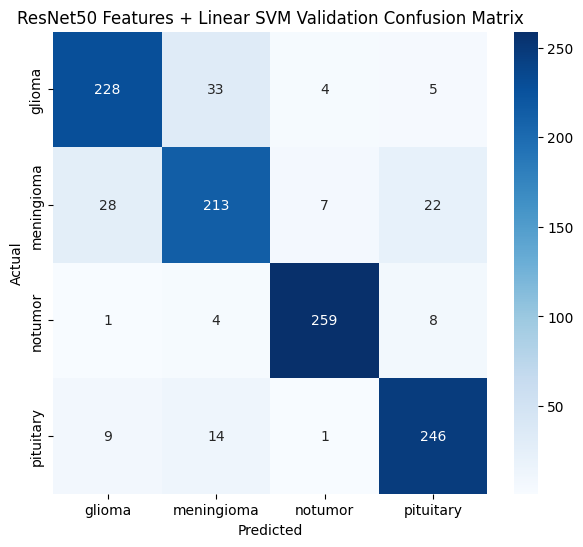


===== ResNet50 Features + Logistic Regression Validation Evaluation =====
Accuracy : 0.8891
Precision: 0.8879
Recall   : 0.8891
F1-score : 0.8883

Classification Report:
              precision    recall  f1-score   support

      glioma       0.87      0.89      0.88       270
  meningioma       0.83      0.78      0.80       270
     notumor       0.95      0.96      0.95       272
   pituitary       0.91      0.93      0.92       270

    accuracy                           0.89      1082
   macro avg       0.89      0.89      0.89      1082
weighted avg       0.89      0.89      0.89      1082



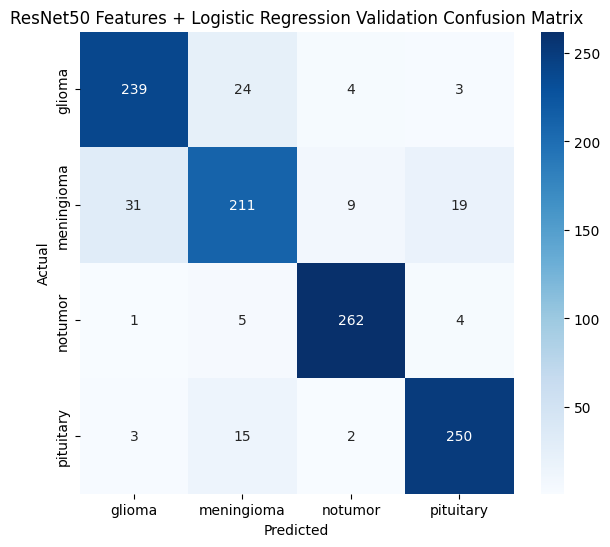


===== ResNet50 Features + Linear SVM Test Evaluation =====
Accuracy : 0.8780
Precision: 0.8771
Recall   : 0.8780
F1-score : 0.8775

Classification Report:
              precision    recall  f1-score   support

      glioma       0.85      0.86      0.85       270
  meningioma       0.81      0.78      0.79       270
     notumor       0.96      0.97      0.96       272
   pituitary       0.89      0.90      0.90       270

    accuracy                           0.88      1082
   macro avg       0.88      0.88      0.88      1082
weighted avg       0.88      0.88      0.88      1082



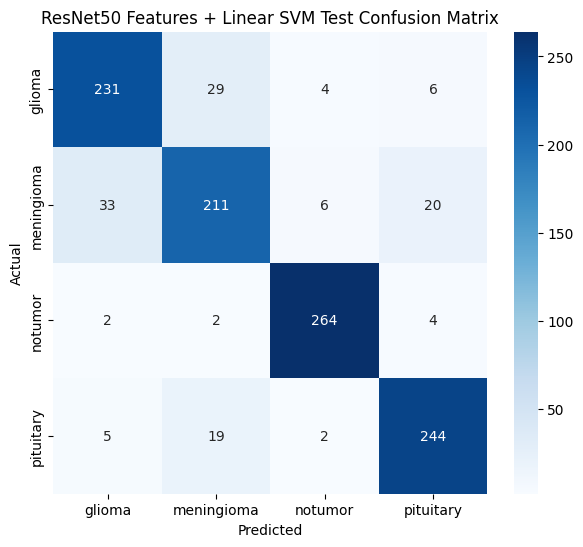


===== ResNet50 Features + Logistic Regression Test Evaluation =====
Accuracy : 0.8919
Precision: 0.8904
Recall   : 0.8919
F1-score : 0.8907

Classification Report:
              precision    recall  f1-score   support

      glioma       0.87      0.87      0.87       270
  meningioma       0.84      0.78      0.81       270
     notumor       0.94      0.97      0.95       272
   pituitary       0.91      0.94      0.93       270

    accuracy                           0.89      1082
   macro avg       0.89      0.89      0.89      1082
weighted avg       0.89      0.89      0.89      1082



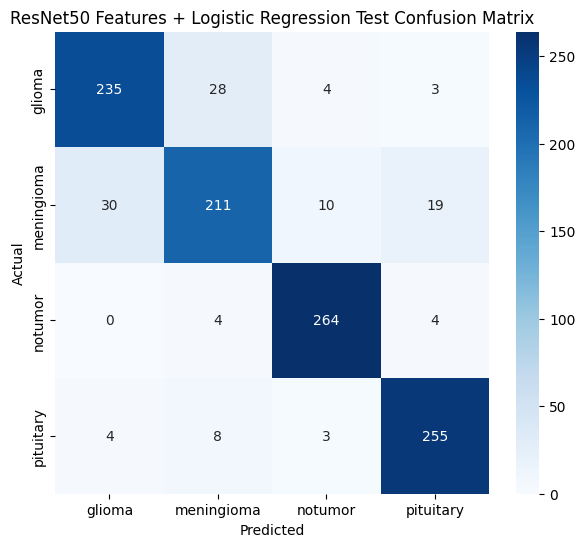

In [14]:
# =========================
# Validation Evaluation
# =========================
svm_val_metrics = evaluate_ml_model(
    svm_model,
    X_val,
    y_val,
    "ResNet50 Features + Linear SVM Validation"
)

log_val_metrics = evaluate_ml_model(
    log_model,
    X_val,
    y_val,
    "ResNet50 Features + Logistic Regression Validation"
)

# =========================
# Test Evaluation
# =========================
svm_test_metrics = evaluate_ml_model(
    svm_model,
    X_test,
    y_test,
    "ResNet50 Features + Linear SVM Test"
)

log_test_metrics = evaluate_ml_model(
    log_model,
    X_test,
    y_test,
    "ResNet50 Features + Logistic Regression Test"
)

In [15]:
comparison_approach1 = pd.DataFrame({
    "Model": [
        "ResNet50 Features + Linear SVM",
        "ResNet50 Features + Logistic Regression"
    ],
    "Accuracy": [
        svm_test_metrics[0],
        log_test_metrics[0]
    ],
    "Precision": [
        svm_test_metrics[1],
        log_test_metrics[1]
    ],
    "Recall": [
        svm_test_metrics[2],
        log_test_metrics[2]
    ],
    "F1-score": [
        svm_test_metrics[3],
        log_test_metrics[3]
    ]
})

print("Approach 1 Test Comparison:")
display(comparison_approach1)

Approach 1 Test Comparison:


,Model,Accuracy,Precision,Recall,F1-score
0,ResNet50 Features + Linear SVM,0.878004,0.877112,0.878004,0.877475
1,ResNet50 Features + Logistic Regression,0.891867,0.890396,0.891867,0.890706


**Approach 2: ResNet50 End-to-End.** Imports + Settings

In [16]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLASSES = len(class_names)
print("Number of classes:", NUM_CLASSES)
print("Classes:", class_names)

EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 5

BEST_MODEL_PATH = "/content/drive/MyDrive/datasets/best_resnet50_end_to_end.pth"

Using device: cuda
Number of classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


**Build ResNet50 End-to-End Model**

In [17]:
# Load pretrained ResNet50
weights = ResNet50_Weights.DEFAULT
resnet_model = resnet50(weights=weights)

# Replace final classification layer
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, NUM_CLASSES)

resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()

print(resnet_model.fc)
print("ResNet50 End-to-End Model Ready ✅")

Linear(in_features=2048, out_features=4, bias=True)
ResNet50 End-to-End Model Ready ✅


**Training and Validation Functions**

In [18]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total = 0
    correct = 0
    running_loss = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc


def validate(model, loader, criterion):
    model.eval()

    total = 0
    correct = 0
    running_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc

**Train Classifier Only**

In [25]:
print("================ STAGE 1: Train final classifier only ================")

# Freeze all layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Train only final FC layer
for param in resnet_model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    resnet_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0

for_epoch_range = range(EPOCHS_STAGE1)

================ STAGE 1: Train final classifier only ================


In [26]:
print("================ STAGE 1: Train final classifier only ================")

# Freeze all layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Train only final FC layer
for param in resnet_model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    resnet_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0

for epoch in range(EPOCHS_STAGE1):
    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        resnet_model,
        val_loader,
        criterion
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"\nStage 1 Epoch {epoch+1}/{EPOCHS_STAGE1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet_model.state_dict(), BEST_MODEL_PATH)
        print("✅ Best model saved")

================ STAGE 1: Train final classifier only ================


100%|██████████| 158/158 [00:59<00:00,  2.67it/s]



Stage 1 Epoch 1/5
Train Loss: 0.1996
Train Acc : 92.71%
Val Loss  : 0.1960
Val Acc   : 92.70%
✅ Best model saved


100%|██████████| 158/158 [00:52<00:00,  2.98it/s]



Stage 1 Epoch 2/5
Train Loss: 0.1935
Train Acc : 93.23%
Val Loss  : 0.1953
Val Acc   : 92.51%


...


Stage 1 Epoch 3/5
Train Loss: 0.1658
Train Acc : 93.62%
Val Loss  : 0.1924
Val Acc   : 93.44%
✅ Best model saved


100%|██████████| 158/158 [00:53<00:00,  2.98it/s]



Stage 1 Epoch 4/5
Train Loss: 0.1641
Train Acc : 93.80%
Val Loss  : 0.2164
Val Acc   : 92.98%


100%|██████████| 158/158 [00:51<00:00,  3.06it/s]



Stage 1 Epoch 5/5
Train Loss: 0.1631
Train Acc : 94.26%
Val Loss  : 0.1913
Val Acc   : 93.35%


**Stage 2: Fine-tune layer4 + classifier**

In [27]:
print("================ STAGE 2: Fine-tune ResNet50 layer4 + classifier ================")

# Unfreeze last block
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

# Make sure classifier is trainable
for param in resnet_model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {"params": resnet_model.layer4.parameters(), "lr": 1e-4},
    {"params": resnet_model.fc.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

for epoch in range(EPOCHS_STAGE2):
    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        resnet_model,
        val_loader,
        criterion
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"\nStage 2 Epoch {epoch+1}/{EPOCHS_STAGE2}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet_model.state_dict(), BEST_MODEL_PATH)
        print("✅ Best model saved")

print("\nBest Validation Accuracy:", best_val_acc)
print("Best model path:", BEST_MODEL_PATH)

================ STAGE 2: Fine-tune ResNet50 layer4 + classifier ================


100%|██████████| 158/158 [00:53<00:00,  2.97it/s]



Stage 2 Epoch 1/5
Train Loss: 0.1646
Train Acc : 94.22%
Val Loss  : 0.1765
Val Acc   : 94.09%
✅ Best model saved


100%|██████████| 158/158 [00:56<00:00,  2.81it/s]



Stage 2 Epoch 2/5
Train Loss: 0.1199
Train Acc : 95.78%
Val Loss  : 0.1636
Val Acc   : 95.47%
✅ Best model saved


...


Stage 2 Epoch 3/5
Train Loss: 0.0784
Train Acc : 96.95%
Val Loss  : 0.1160
Val Acc   : 96.40%
✅ Best model saved


100%|██████████| 158/158 [00:55<00:00,  2.84it/s]



Stage 2 Epoch 4/5
Train Loss: 0.0686
Train Acc : 97.70%
Val Loss  : 0.1327
Val Acc   : 96.21%


100%|██████████| 158/158 [00:55<00:00,  2.87it/s]



Stage 2 Epoch 5/5
Train Loss: 0.0561
Train Acc : 97.98%
Val Loss  : 0.1217
Val Acc   : 96.67%
✅ Best model saved

Best Validation Accuracy: 96.6728280961183
Best model path: /content/drive/MyDrive/datasets/best_resnet50_end_to_end.pth


**Load Best Model + Test Evaluation**

In [28]:
# Load best model
try:
    state_dict = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(BEST_MODEL_PATH, map_location=device)

resnet_model.load_state_dict(state_dict)
resnet_model = resnet_model.to(device)
resnet_model.eval()

print("✅ Best ResNet50 End-to-End model loaded")


def evaluate_end_to_end(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = evaluate_end_to_end(resnet_model, test_loader)

resnet_e2e_acc = accuracy_score(y_true, y_pred)
resnet_e2e_precision = precision_score(y_true, y_pred, average="weighted")
resnet_e2e_recall = recall_score(y_true, y_pred, average="weighted")
resnet_e2e_f1 = f1_score(y_true, y_pred, average="weighted")

print("\n===== RESNET50 END-TO-END TEST RESULTS =====")
print(f"Accuracy  : {resnet_e2e_acc:.4f}")
print(f"Precision : {resnet_e2e_precision:.4f}")
print(f"Recall    : {resnet_e2e_recall:.4f}")
print(f"F1-score  : {resnet_e2e_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

✅ Best ResNet50 End-to-End model loaded

===== RESNET50 END-TO-END TEST RESULTS =====
Accuracy  : 0.9760
Precision : 0.9767
Recall    : 0.9760
F1-score  : 0.9760

Classification Report:

              precision    recall  f1-score   support

      glioma       0.99      0.94      0.97       270
  meningioma       0.94      0.99      0.96       270
     notumor       0.99      1.00      0.99       272
   pituitary       0.99      0.98      0.99       270

    accuracy                           0.98      1082
   macro avg       0.98      0.98      0.98      1082
weighted avg       0.98      0.98      0.98      1082



**Confusion Matrix**

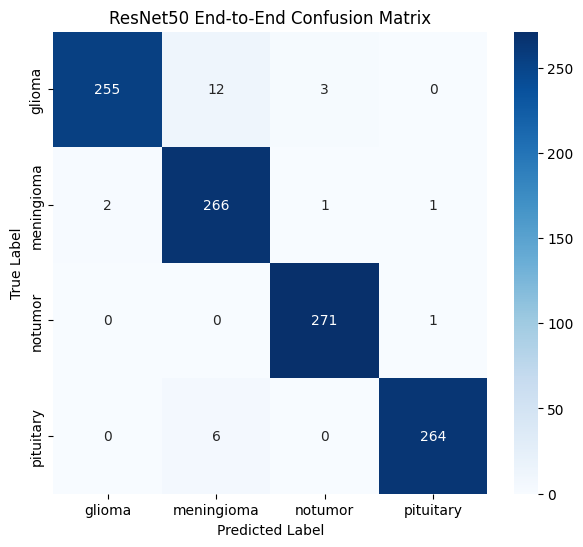

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ResNet50 End-to-End Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Learning Curves**

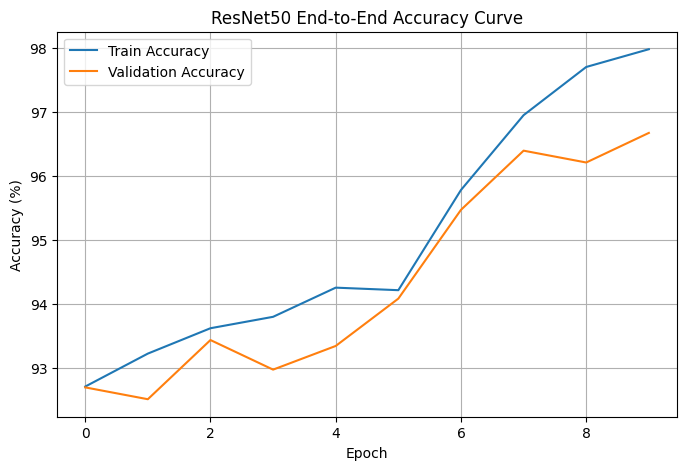

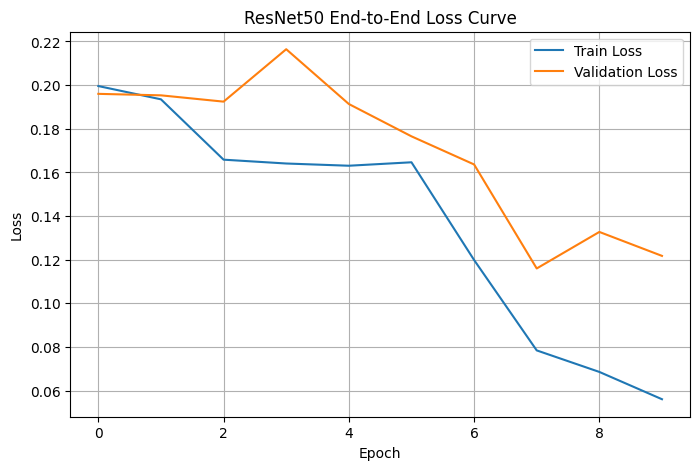

,Model,Accuracy,Precision,Recall,F1-score
0,ResNet50 End-to-End,0.97597,0.97671,0.97597,0.976019


In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("ResNet50 End-to-End Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("ResNet50 End-to-End Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
resnet_e2e_results = pd.DataFrame({
    "Model": ["ResNet50 End-to-End"],
    "Accuracy": [resnet_e2e_acc],
    "Precision": [resnet_e2e_precision],
    "Recall": [resnet_e2e_recall],
    "F1-score": [resnet_e2e_f1]
})

display(resnet_e2e_results)

**Bonus:**


**EfficientNet-B0 Extra CNN Model**

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 5

BEST_EFFICIENTNET_PATH = "/content/drive/MyDrive/datasets/best_efficientnet_b0_bonus.pth"

Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


**Build EfficientNet-B0 Model**

In [32]:
weights = models.EfficientNet_B0_Weights.DEFAULT

efficientnet_model = models.efficientnet_b0(weights=weights)

# Replace classifier layer
in_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

efficientnet_model = efficientnet_model.to(device)

criterion = nn.CrossEntropyLoss()

print(efficientnet_model.classifier)
print("EfficientNet-B0 Bonus Model Ready ✅")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)
EfficientNet-B0 Bonus Model Ready ✅


In [33]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total = 0
    correct = 0
    running_loss = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc


def validate(model, loader, criterion):
    model.eval()

    total = 0
    correct = 0
    running_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc

In [34]:
print("================ BONUS STAGE 1: Train EfficientNet-B0 classifier only ================")

# Freeze all model layers
for param in efficientnet_model.parameters():
    param.requires_grad = False

# Train only classifier
for param in efficientnet_model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    efficientnet_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

efficientnet_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_eff_val_acc = 0.0

for epoch in range(EPOCHS_STAGE1):
    train_loss, train_acc = train_one_epoch(
        efficientnet_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        efficientnet_model,
        val_loader,
        criterion
    )

    efficientnet_history["train_loss"].append(train_loss)
    efficientnet_history["val_loss"].append(val_loss)
    efficientnet_history["train_acc"].append(train_acc)
    efficientnet_history["val_acc"].append(val_acc)

    print(f"\nBonus Stage 1 Epoch {epoch+1}/{EPOCHS_STAGE1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_eff_val_acc:
        best_eff_val_acc = val_acc
        torch.save(efficientnet_model.state_dict(), BEST_EFFICIENTNET_PATH)
        print("✅ Best EfficientNet-B0 saved")

================ BONUS STAGE 1: Train EfficientNet-B0 classifier only ================


100%|██████████| 158/158 [00:48<00:00,  3.29it/s]



Bonus Stage 1 Epoch 1/5
Train Loss: 0.6661
Train Acc : 78.00%
Val Loss  : 0.4607
Val Acc   : 82.81%
✅ Best EfficientNet-B0 saved


100%|██████████| 158/158 [00:47<00:00,  3.30it/s]



Bonus Stage 1 Epoch 2/5
Train Loss: 0.4525
Train Acc : 84.79%
Val Loss  : 0.3819
Val Acc   : 85.58%
✅ Best EfficientNet-B0 saved


...


Bonus Stage 1 Epoch 3/5
Train Loss: 0.4034
Train Acc : 86.02%
Val Loss  : 0.3581
Val Acc   : 87.52%
✅ Best EfficientNet-B0 saved


100%|██████████| 158/158 [00:49<00:00,  3.20it/s]



Bonus Stage 1 Epoch 4/5
Train Loss: 0.3922
Train Acc : 86.12%
Val Loss  : 0.3367
Val Acc   : 88.35%
✅ Best EfficientNet-B0 saved


100%|██████████| 158/158 [00:48<00:00,  3.26it/s]



Bonus Stage 1 Epoch 5/5
Train Loss: 0.3688
Train Acc : 86.77%
Val Loss  : 0.3318
Val Acc   : 88.17%


In [35]:
print("================ BONUS STAGE 2: Fine-tune EfficientNet-B0 last blocks ================")

# Unfreeze last blocks
for param in efficientnet_model.features[-2:].parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in efficientnet_model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {"params": efficientnet_model.features[-2:].parameters(), "lr": 1e-4},
    {"params": efficientnet_model.classifier.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

for epoch in range(EPOCHS_STAGE2):
    train_loss, train_acc = train_one_epoch(
        efficientnet_model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        efficientnet_model,
        val_loader,
        criterion
    )

    efficientnet_history["train_loss"].append(train_loss)
    efficientnet_history["val_loss"].append(val_loss)
    efficientnet_history["train_acc"].append(train_acc)
    efficientnet_history["val_acc"].append(val_acc)

    print(f"\nBonus Stage 2 Epoch {epoch+1}/{EPOCHS_STAGE2}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_eff_val_acc:
        best_eff_val_acc = val_acc
        torch.save(efficientnet_model.state_dict(), BEST_EFFICIENTNET_PATH)
        print("✅ Best EfficientNet-B0 saved")

print("\nBest EfficientNet-B0 Validation Accuracy:", best_eff_val_acc)
print("Best model path:", BEST_EFFICIENTNET_PATH)

================ BONUS STAGE 2: Fine-tune EfficientNet-B0 last blocks ================


100%|██████████| 158/158 [00:48<00:00,  3.29it/s]



Bonus Stage 2 Epoch 1/5
Train Loss: 0.3323
Train Acc : 88.29%
Val Loss  : 0.2729
Val Acc   : 89.83%
✅ Best EfficientNet-B0 saved


100%|██████████| 158/158 [00:48<00:00,  3.28it/s]



Bonus Stage 2 Epoch 2/5
Train Loss: 0.2662
Train Acc : 90.00%
Val Loss  : 0.2649
Val Acc   : 89.83%


...


Bonus Stage 2 Epoch 3/5
Train Loss: 0.2250
Train Acc : 92.02%
Val Loss  : 0.2163
Val Acc   : 91.96%
✅ Best EfficientNet-B0 saved


100%|██████████| 158/158 [00:49<00:00,  3.22it/s]



Bonus Stage 2 Epoch 4/5
Train Loss: 0.2070
Train Acc : 92.59%
Val Loss  : 0.1946
Val Acc   : 92.98%
✅ Best EfficientNet-B0 saved


100%|██████████| 158/158 [00:47<00:00,  3.32it/s]



Bonus Stage 2 Epoch 5/5
Train Loss: 0.1917
Train Acc : 93.15%
Val Loss  : 0.1806
Val Acc   : 93.53%
✅ Best EfficientNet-B0 saved

Best EfficientNet-B0 Validation Accuracy: 93.53049907578558
Best model path: /content/drive/MyDrive/datasets/best_efficientnet_b0_bonus.pth


In [36]:
try:
    state_dict = torch.load(BEST_EFFICIENTNET_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(BEST_EFFICIENTNET_PATH, map_location=device)

efficientnet_model.load_state_dict(state_dict)
efficientnet_model = efficientnet_model.to(device)
efficientnet_model.eval()

print("✅ Best EfficientNet-B0 Bonus model loaded")


def evaluate_bonus_model(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


eff_y_true, eff_y_pred = evaluate_bonus_model(efficientnet_model, test_loader)

efficientnet_acc = accuracy_score(eff_y_true, eff_y_pred)
efficientnet_precision = precision_score(eff_y_true, eff_y_pred, average="weighted")
efficientnet_recall = recall_score(eff_y_true, eff_y_pred, average="weighted")
efficientnet_f1 = f1_score(eff_y_true, eff_y_pred, average="weighted")

print("\n===== BONUS EFFICIENTNET-B0 TEST RESULTS =====")
print(f"Accuracy  : {efficientnet_acc:.4f}")
print(f"Precision : {efficientnet_precision:.4f}")
print(f"Recall    : {efficientnet_recall:.4f}")
print(f"F1-score  : {efficientnet_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(eff_y_true, eff_y_pred, target_names=class_names))

✅ Best EfficientNet-B0 Bonus model loaded

===== BONUS EFFICIENTNET-B0 TEST RESULTS =====
Accuracy  : 0.9409
Precision : 0.9420
Recall    : 0.9409
F1-score  : 0.9409

Classification Report:

              precision    recall  f1-score   support

      glioma       0.97      0.90      0.93       270
  meningioma       0.87      0.91      0.89       270
     notumor       0.95      0.99      0.97       272
   pituitary       0.97      0.97      0.97       270

    accuracy                           0.94      1082
   macro avg       0.94      0.94      0.94      1082
weighted avg       0.94      0.94      0.94      1082



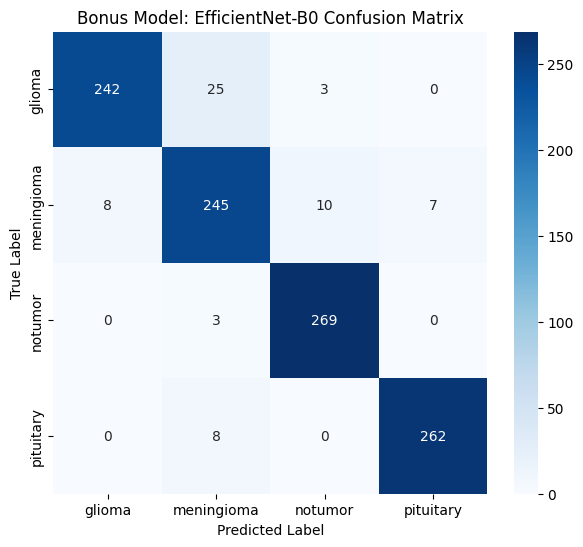

In [37]:
eff_cm = confusion_matrix(eff_y_true, eff_y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    eff_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Bonus Model: EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

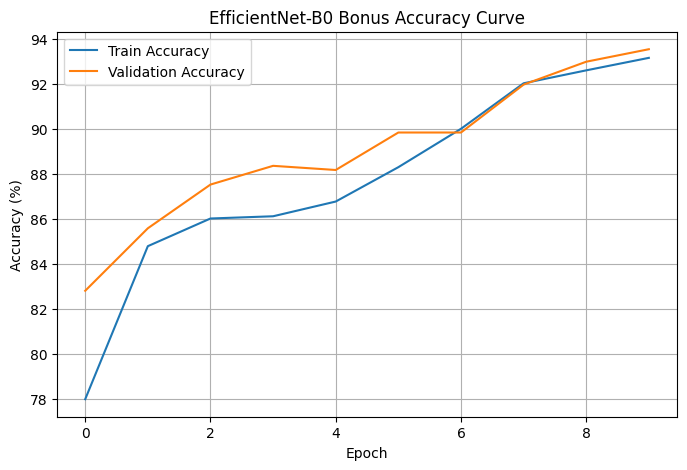

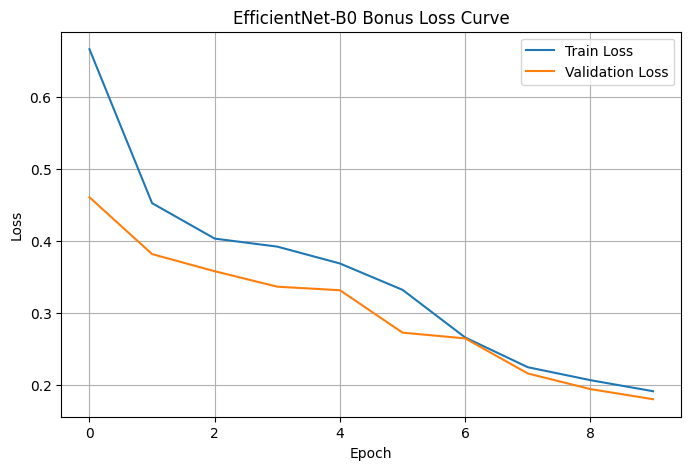

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(efficientnet_history["train_acc"], label="Train Accuracy")
plt.plot(efficientnet_history["val_acc"], label="Validation Accuracy")
plt.title("EfficientNet-B0 Bonus Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(efficientnet_history["train_loss"], label="Train Loss")
plt.plot(efficientnet_history["val_loss"], label="Validation Loss")
plt.title("EfficientNet-B0 Bonus Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
efficientnet_bonus_results = pd.DataFrame({
    "Model": ["EfficientNet-B0 Bonus Extra CNN"],
    "Accuracy": [efficientnet_acc],
    "Precision": [efficientnet_precision],
    "Recall": [efficientnet_recall],
    "F1-score": [efficientnet_f1]
})

display(efficientnet_bonus_results)

,Model,Accuracy,Precision,Recall,F1-score
0,EfficientNet-B0 Bonus Extra CNN,0.94085,0.941963,0.94085,0.940894


In [3]:
from torchvision import transforms

IMG_SIZE = 224

In [4]:
# =========================
# Training Transforms
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),

    # Convert to tensor
    transforms.ToTensor(),

    # Normalization (grayscale MRI safe)
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [5]:
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [6]:
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [7]:
from torchvision import transforms

IMG_SIZE = 224

# =========================
# Training Transforms
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),

    # Convert grayscale MRI to 3 channels for pretrained models
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# =========================
# Validation Transforms
# =========================
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# =========================
# Test Transforms
# =========================
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [11]:
OUTPUT_DIR = "/content/drive/MyDrive/datasets/brain-tumor-mri"

In [12]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

BATCH_SIZE = 32

train_path = os.path.join(OUTPUT_DIR, "train")
val_path   = os.path.join(OUTPUT_DIR, "val")
test_path  = os.path.join(OUTPUT_DIR, "test")

train_dataset = ImageFolder(train_path, transform=train_transforms)
val_dataset   = ImageFolder(val_path, transform=val_transforms)
test_dataset  = ImageFolder(test_path, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Class to idx:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to idx: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train size: 5054
Val size:   1080
Test size:  1080


In [13]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

BATCH_SIZE = 32

train_path = os.path.join(OUTPUT_DIR, "train")
val_path   = os.path.join(OUTPUT_DIR, "val")
test_path  = os.path.join(OUTPUT_DIR, "test")

train_dataset = ImageFolder(train_path, transform=train_transforms)
val_dataset   = ImageFolder(val_path, transform=val_transforms)
test_dataset  = ImageFolder(test_path, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Class to idx:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to idx: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train size: 5054
Val size:   1080
Test size:  1080


In [14]:
import os

for split in ["train", "val", "test"]:
    print(f"\n===== {split.upper()} =====")
    split_path = os.path.join(OUTPUT_DIR, split)

    total = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        count = len(os.listdir(cls_path))
        total += count
        print(f"{cls}: {count}")

    print("Total:", total)


===== TRAIN =====
glioma: 1260
meningioma: 1273
notumor: 1261
pituitary: 1260
Total: 5054

===== VAL =====
glioma: 270
meningioma: 270
notumor: 270
pituitary: 270
Total: 1080

===== TEST =====
glioma: 270
meningioma: 270
notumor: 270
pituitary: 270
Total: 1080


In [16]:
import torch
import torchvision
import torchvision.models as models
from tqdm import tqdm
import numpy as np

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [18]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


In [19]:
model = torch.nn.Sequential(*list(model.children())[:-1])
model = model.to(device)

In [20]:
for param in model.parameters():
    param.requires_grad = False

model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [21]:
# Install (run once)
# !pip install torch torchvision torchaudio

# Imports
import torch
import torchvision
from torchvision.models import resnet50, ResNet50_Weights

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load ResNet50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Remove classifier
model = torch.nn.Sequential(*list(model.children())[:-1])

# Freeze parameters
for param in model.parameters():
    param.requires_grad = False

model = model.to(device)
model.eval()

print("Feature Extractor Ready ✅")

Using device: cuda
Feature Extractor Ready ✅


In [22]:
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet50_Weights.DEFAULT
feature_extractor = resnet50(weights=weights)

# حذف طبقة التصنيف
feature_extractor = torch.nn.Sequential(
    *list(feature_extractor.children())[:-1]
)

# Freeze parameters
for param in feature_extractor.parameters():
    param.requires_grad = False

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("✅ Feature Extractor Ready")

✅ Feature Extractor Ready


Using device: cuda
Train path: /content/drive/MyDrive/datasets/brain-tumor-mri/train
Val path:   /content/drive/MyDrive/datasets/brain-tumor-mri/val
Test path:  /content/drive/MyDrive/datasets/brain-tumor-mri/test

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to idx: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train size: 5054
Val size:   1080
Test size:  1080

================ CLASS COUNTS ================

===== TRAIN =====
glioma: 1260
meningioma: 1273
notumor: 1261
pituitary: 1260
Total: 5054

===== VAL =====
glioma: 270
meningioma: 270
notumor: 270
pituitary: 270
Total: 1080

===== TEST =====
glioma: 270
meningioma: 270
notumor: 270
pituitary: 270
Total: 1080

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])

Feature Extractor Ready ✅

Extracting train features...


100%|██████████| 158/158 [07:57<00:00,  3.02s/it]



Extracting validation features...


100%|██████████| 34/34 [02:18<00:00,  4.08s/it]



Extracting test features...


100%|██████████| 34/34 [02:14<00:00,  3.97s/it]



Train Features Shape: (5054, 2048)
Val Features Shape:   (1080, 2048)
Test Features Shape:  (1080, 2048)

Training SVM...
Training Logistic Regression...
Training Finished ✅

===== SVM Validation Evaluation =====
Accuracy : 0.9166666666666666
Precision: 0.9170253831449062
Recall   : 0.9166666666666666
F1-score : 0.9164898275233981
AUC      : 0.9900571559213535

Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.86      0.89       270
  meningioma       0.83      0.86      0.85       270
     notumor       0.97      0.98      0.98       270
   pituitary       0.94      0.97      0.95       270

    accuracy                           0.92      1080
   macro avg       0.92      0.92      0.92      1080
weighted avg       0.92      0.92      0.92      1080



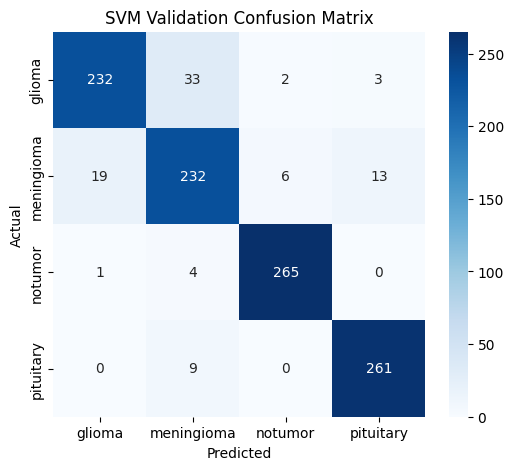


===== Logistic Regression Validation Evaluation =====
Accuracy : 0.8944444444444445
Precision: 0.8931012856798982
Recall   : 0.8944444444444445
F1-score : 0.8928733135256856
AUC      : 0.9831138545953362

Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.83      0.87       270
  meningioma       0.83      0.79      0.81       270
     notumor       0.94      0.98      0.96       270
   pituitary       0.90      0.98      0.94       270

    accuracy                           0.89      1080
   macro avg       0.89      0.89      0.89      1080
weighted avg       0.89      0.89      0.89      1080



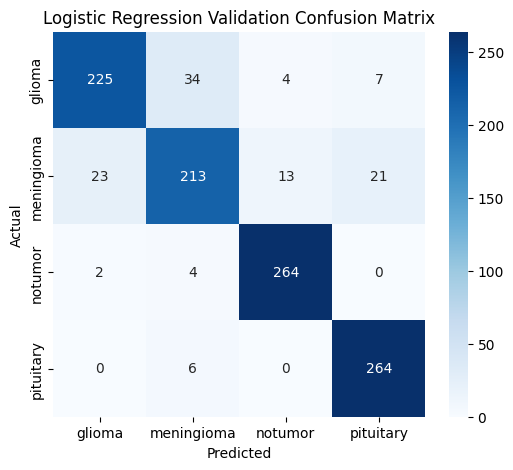


===== SVM Test Evaluation =====
Accuracy : 0.9351851851851852
Precision: 0.9354811413762122
Recall   : 0.9351851851851852
F1-score : 0.9350270483703267
AUC      : 0.9915580704160951

Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.89      0.91       270
  meningioma       0.87      0.90      0.88       270
     notumor       0.96      0.99      0.97       270
   pituitary       0.97      0.97      0.97       270

    accuracy                           0.94      1080
   macro avg       0.94      0.94      0.94      1080
weighted avg       0.94      0.94      0.94      1080



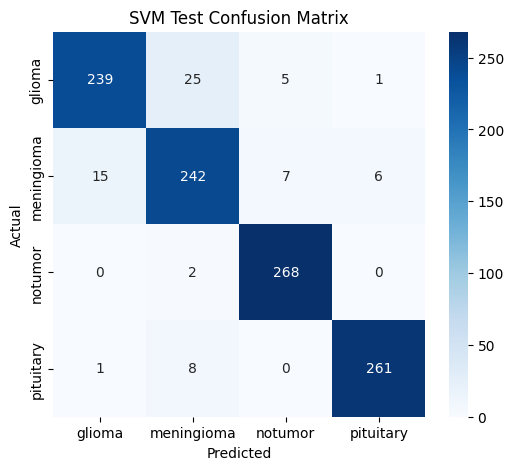


===== Logistic Regression Test Evaluation =====
Accuracy : 0.9064814814814814
Precision: 0.9068147190902313
Recall   : 0.9064814814814814
F1-score : 0.9060617587316758
AUC      : 0.9851428898033836

Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.84      0.88       270
  meningioma       0.83      0.85      0.84       270
     notumor       0.94      0.99      0.96       270
   pituitary       0.94      0.94      0.94       270

    accuracy                           0.91      1080
   macro avg       0.91      0.91      0.91      1080
weighted avg       0.91      0.91      0.91      1080



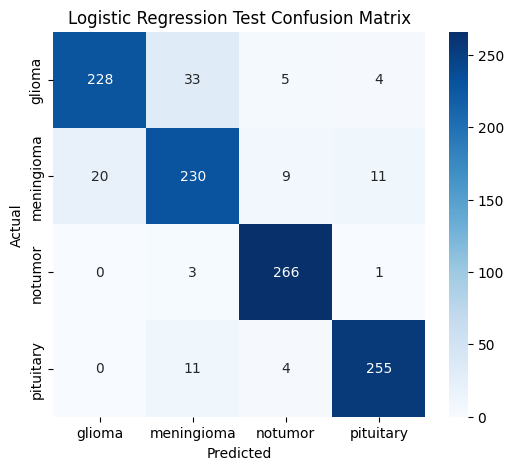


Final Test Comparison:


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,SVM,0.935185,0.935481,0.935185,0.935027,0.991558
1,Logistic Regression,0.906481,0.906815,0.906481,0.906062,0.985143


In [24]:
# ============================================================
# ONE CELL - Use Existing train/val/test folders
# Path: /content/drive/MyDrive/datasets/brain-tumor-mri
# ResNet50 Feature Extractor + SVM + Logistic Regression
# ============================================================

# لو الدرايف مش معمول Mount شيل التعليق من السطرين دول
# from google.colab import drive
# drive.mount('/content/drive')

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================
# Settings
# =========================
DATASET_DIR = "/content/drive/MyDrive/datasets/brain-tumor-mri"

train_path = os.path.join(DATASET_DIR, "train")
val_path   = os.path.join(DATASET_DIR, "val")
test_path  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
RANDOM_STATE = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Check paths
# =========================
for path in [train_path, val_path, test_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Folder not found: {path}")

print("Train path:", train_path)
print("Val path:  ", val_path)
print("Test path: ", test_path)

# =========================
# Transforms
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),

    # ResNet50 needs 3 channels
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    # ImageNet normalization because ResNet50 is pretrained on ImageNet
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# Datasets and DataLoaders
# =========================
train_dataset = ImageFolder(train_path, transform=train_transforms)
val_dataset   = ImageFolder(val_path, transform=val_transforms)
test_dataset  = ImageFolder(test_path, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

class_names = train_dataset.classes

print("\nClasses:", class_names)
print("Class to idx:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

# =========================
# Check class distribution
# =========================
print("\n================ CLASS COUNTS ================")

for split_name, path in [("TRAIN", train_path), ("VAL", val_path), ("TEST", test_path)]:
    print(f"\n===== {split_name} =====")
    total = 0
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            total += count
            print(f"{cls}: {count}")
    print("Total:", total)

# =========================
# Check batch shape
# =========================
images, labels = next(iter(train_loader))
print("\nBatch image shape:", images.shape)
print("Batch label shape:", labels.shape)

# =========================
# ResNet50 Feature Extractor
# =========================
weights = ResNet50_Weights.DEFAULT
feature_extractor = resnet50(weights=weights)

# remove classifier layer
feature_extractor = torch.nn.Sequential(
    *list(feature_extractor.children())[:-1]
)

for param in feature_extractor.parameters():
    param.requires_grad = False

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("\nFeature Extractor Ready ✅")

# =========================
# Feature Extraction Function
# =========================
def extract_features(model, loader):
    all_features = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)

            outputs = model(images)

            # [batch, 2048, 1, 1] -> [batch, 2048]
            outputs = outputs.view(outputs.size(0), -1)

            all_features.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y

# =========================
# Extract Features
# =========================
print("\nExtracting train features...")
X_train, y_train = extract_features(feature_extractor, train_loader)

print("\nExtracting validation features...")
X_val, y_val = extract_features(feature_extractor, val_loader)

print("\nExtracting test features...")
X_test, y_test = extract_features(feature_extractor, test_loader)

print("\nTrain Features Shape:", X_train.shape)
print("Val Features Shape:  ", X_val.shape)
print("Test Features Shape: ", X_test.shape)

# =========================
# ML Models
# =========================
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=RANDOM_STATE
)

log_model = LogisticRegression(
    max_iter=3000,
    C=0.5,
    solver="saga",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# =========================
# Train Models
# =========================
print("\nTraining SVM...")
svm_model.fit(X_train, y_train)

print("Training Logistic Regression...")
log_model.fit(X_train, y_train)

print("Training Finished ✅")

# =========================
# Evaluation Function
# =========================
def evaluate_model(model, X, y, model_name="Model"):
    preds = model.predict(X)
    probs = model.predict_proba(X)

    acc = accuracy_score(y, preds)
    precision = precision_score(y, preds, average="weighted")
    recall = recall_score(y, preds, average="weighted")
    f1 = f1_score(y, preds, average="weighted")
    auc = roc_auc_score(y, probs, multi_class="ovr")

    print(f"\n===== {model_name} Evaluation =====")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)
    print("AUC      :", auc)

    print("\nClassification Report:")
    print(classification_report(y, preds, target_names=class_names))

    cm = confusion_matrix(y, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, precision, recall, f1, auc

# =========================
# Validation Evaluation
# =========================
svm_val_metrics = evaluate_model(
    svm_model,
    X_val,
    y_val,
    "SVM Validation"
)

log_val_metrics = evaluate_model(
    log_model,
    X_val,
    y_val,
    "Logistic Regression Validation"
)

# =========================
# Test Evaluation
# =========================
svm_test_metrics = evaluate_model(
    svm_model,
    X_test,
    y_test,
    "SVM Test"
)

log_test_metrics = evaluate_model(
    log_model,
    X_test,
    y_test,
    "Logistic Regression Test"
)

# =========================
# Final Comparison
# =========================
comparison = pd.DataFrame({
    "Model": ["SVM", "Logistic Regression"],
    "Accuracy": [svm_test_metrics[0], log_test_metrics[0]],
    "Precision": [svm_test_metrics[1], log_test_metrics[1]],
    "Recall": [svm_test_metrics[2], log_test_metrics[2]],
    "F1-score": [svm_test_metrics[3], log_test_metrics[3]],
    "AUC": [svm_test_metrics[4], log_test_metrics[4]]
})

print("\nFinal Test Comparison:")
display(comparison)

Using device: cuda
Train path: /content/drive/MyDrive/datasets/brain-tumor-mri/train
Val path:   /content/drive/MyDrive/datasets/brain-tumor-mri/val
Test path:  /content/drive/MyDrive/datasets/brain-tumor-mri/test

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to idx: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train size: 5054
Val size:   1080
Test size:  1080

================ CLASS COUNTS ================

===== TRAIN =====
glioma: 1260
meningioma: 1273
notumor: 1261
pituitary: 1260
Total: 5054

===== VAL =====
glioma: 270
meningioma: 270
notumor: 270
pituitary: 270
Total: 1080

===== TEST =====
glioma: 270
meningioma: 270
notumor: 270
pituitary: 270
Total: 1080
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 105MB/s]



================ STAGE 1: Train classifier only ================


100%|██████████| 158/158 [00:54<00:00,  2.90it/s]



Stage 1 Epoch 1/5
Train Loss: 0.6810
Train Acc : 77.17%
Val Acc   : 80.93%


...


Stage 3 Epoch 8/10
Train Loss: 0.0884
Train Acc : 97.03%
Val Acc   : 97.50%
✅ Best Model Saved


100%|██████████| 158/158 [00:48<00:00,  3.27it/s]



Stage 3 Epoch 9/10
Train Loss: 0.0850
Train Acc : 97.09%
Val Acc   : 97.22%


100%|██████████| 158/158 [00:48<00:00,  3.27it/s]



Stage 3 Epoch 10/10
Train Loss: 0.0750
Train Acc : 97.65%
Val Acc   : 97.78%
✅ Best Model Saved

Best Validation Accuracy: 97.77777777777777
Best model path: /content/drive/MyDrive/datasets/best_efficientnet_b0_brain_tumor.pth

✅ Best model loaded

===== FINAL TEST RESULTS =====
Accuracy  : 0.9713
Precision : 0.9713
Recall    : 0.9713
F1 Score  : 0.9712

Classification Report:

              precision    recall  f1-score   support

      glioma       0.97      0.95      0.96       270
  meningioma       0.95      0.95      0.95       270
     notumor       0.99      0.99      0.99       270
   pituitary       0.97      0.99      0.98       270

    accuracy                           0.97      1080
   macro avg       0.97      0.97      0.97      1080
weighted avg       0.97      0.97      0.97      1080



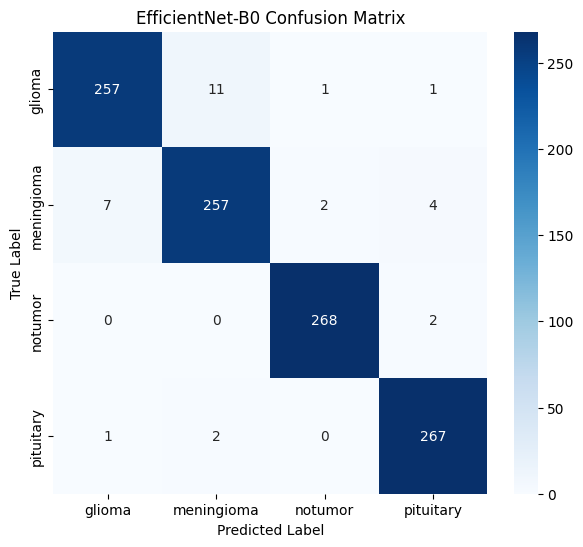

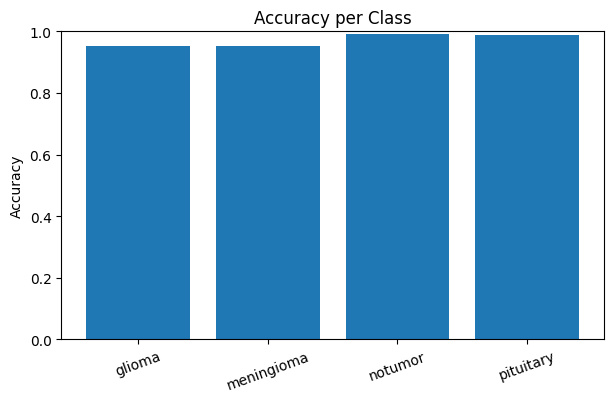

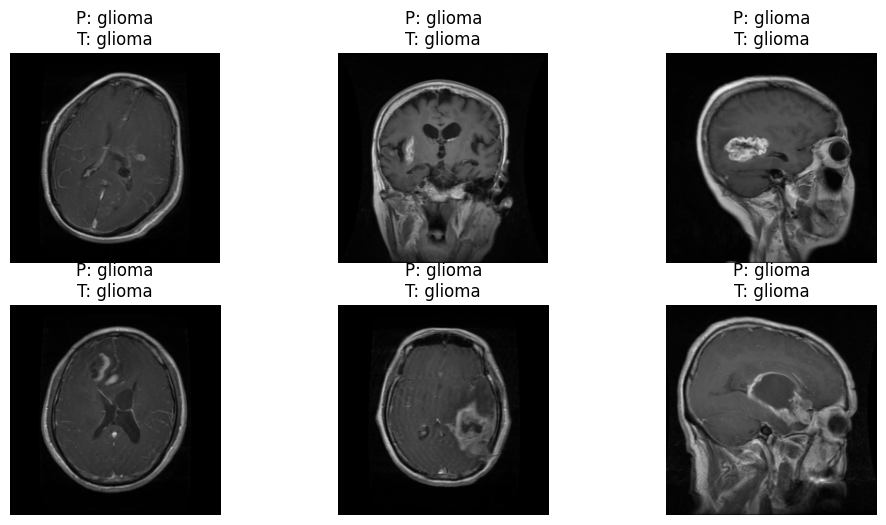

In [25]:
# ============================================================
# ONE CELL - EfficientNet-B0 Training + Fine-tuning + Test Evaluation
# Dataset path: /content/drive/MyDrive/datasets/brain-tumor-mri
# Existing folders: train / val / test
# ============================================================

# لو الدرايف مش معمول mount شيل التعليق من السطرين دول
# from google.colab import drive
# drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# Settings
# =========================
DATASET_DIR = "/content/drive/MyDrive/datasets/brain-tumor-mri"

train_path = os.path.join(DATASET_DIR, "train")
val_path   = os.path.join(DATASET_DIR, "val")
test_path  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
RANDOM_STATE = 42

STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 5
STAGE3_EPOCHS = 10

BEST_MODEL_PATH = "/content/drive/MyDrive/datasets/best_efficientnet_b0_brain_tumor.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Check paths
# =========================
for path in [train_path, val_path, test_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Folder not found: {path}")

print("Train path:", train_path)
print("Val path:  ", val_path)
print("Test path: ", test_path)

# =========================
# Transforms
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),

    # EfficientNet pretrained expects 3 channels
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    # ImageNet normalization for pretrained EfficientNet
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# Datasets and Loaders
# =========================
train_dataset = ImageFolder(train_path, transform=train_transforms)
val_dataset   = ImageFolder(val_path, transform=val_transforms)
test_dataset  = ImageFolder(test_path, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

class_names = train_dataset.classes

print("\nClasses:", class_names)
print("Class to idx:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

# =========================
# Class counts
# =========================
print("\n================ CLASS COUNTS ================")

for split_name, path in [("TRAIN", train_path), ("VAL", val_path), ("TEST", test_path)]:
    print(f"\n===== {split_name} =====")
    total = 0

    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
            ])
            total += count
            print(f"{cls}: {count}")

    print("Total:", total)

# =========================
# Build EfficientNet-B0
# =========================
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# =========================
# Training Functions
# =========================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total = 0
    correct = 0
    loss_sum = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        _, preds = outputs.max(1)

        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    avg_loss = loss_sum / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc


def validate(model, loader):
    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = outputs.max(1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    acc = 100 * correct / total

    return acc


# ============================================================
# STAGE 1: Train classifier only
# ============================================================
print("\n================ STAGE 1: Train classifier only ================")

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

for epoch in range(STAGE1_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc = validate(model, val_loader)

    print(f"\nStage 1 Epoch {epoch+1}/{STAGE1_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Acc   : {val_acc:.2f}%")


# ============================================================
# STAGE 2: Fine-tune last feature blocks + classifier
# ============================================================
print("\n================ STAGE 2: Fine-tune last blocks ================")

for param in model.features[-2:].parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {"params": model.features[-2:].parameters(), "lr": 1e-4},
    {"params": model.classifier.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

for epoch in range(STAGE2_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc = validate(model, val_loader)

    print(f"\nStage 2 Epoch {epoch+1}/{STAGE2_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Acc   : {val_acc:.2f}%")


# ============================================================
# STAGE 3: Fine-tune full model
# ============================================================
print("\n================ STAGE 3: Fine-tune full model ================")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

best_val_acc = 0.0

for epoch in range(STAGE3_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc = validate(model, val_loader)

    print(f"\nStage 3 Epoch {epoch+1}/{STAGE3_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("✅ Best Model Saved")

print("\nBest Validation Accuracy:", best_val_acc)
print("Best model path:", BEST_MODEL_PATH)

# =========================
# Load best model safely
# =========================
try:
    state_dict = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(BEST_MODEL_PATH, map_location=device)

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("\n✅ Best model loaded")

# =========================
# Test Evaluation
# =========================
def evaluate_on_loader(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = evaluate_on_loader(model, test_loader)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("\n===== FINAL TEST RESULTS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()

# =========================
# Accuracy per Class
# =========================
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.bar(class_names, class_accuracy)
plt.title("Accuracy per Class")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

# =========================
# Visualize Predictions without clipping warning
# =========================
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img


def visualize_predictions(model, loader, num_images=6):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(12, 6))

    for i in range(num_images):
        plt.subplot(2, 3, i + 1)

        img = unnormalize(images[i]).permute(1, 2, 0)

        pred_name = class_names[preds[i].item()]
        true_name = class_names[labels[i].item()]

        plt.imshow(img)
        plt.title(f"P: {pred_name}\nT: {true_name}")
        plt.axis("off")

    plt.show()


visualize_predictions(model, test_loader)

Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 5054
Val size:   1080
Test size:  1080

================ BONUS STAGE 1: Train ResNet50 classifier only ================


100%|██████████| 158/158 [00:55<00:00,  2.85it/s]



Stage 1 Epoch 1/5
Train Loss: 0.7674
Train Acc : 75.07%
Val Acc   : 83.52%
✅ Best ResNet50 Saved


100%|██████████| 158/158 [00:46<00:00,  3.40it/s]



Stage 1 Epoch 2/5
Train Loss: 0.5100
Train Acc : 82.49%
Val Acc   : 83.89%
✅ Best ResNet50 Saved


...


Stage 2 Epoch 3/5
Train Loss: 0.0982
Train Acc : 96.30%
Val Acc   : 95.83%
✅ Best ResNet50 Saved


100%|██████████| 158/158 [00:48<00:00,  3.24it/s]



Stage 2 Epoch 4/5
Train Loss: 0.0818
Train Acc : 97.21%
Val Acc   : 95.46%


100%|██████████| 158/158 [00:46<00:00,  3.37it/s]



Stage 2 Epoch 5/5
Train Loss: 0.0573
Train Acc : 97.96%
Val Acc   : 97.22%
✅ Best ResNet50 Saved

Best ResNet50 Validation Accuracy: 97.22222222222223
Best ResNet50 path: /content/drive/MyDrive/datasets/best_resnet50_bonus_brain_tumor.pth

✅ Best ResNet50 loaded

===== BONUS RESNET50 FINAL TEST RESULTS =====
Accuracy  : 0.9741
Precision : 0.9741
Recall    : 0.9741
F1 Score  : 0.9740

Classification Report:

              precision    recall  f1-score   support

      glioma       0.96      0.97      0.97       270
  meningioma       0.97      0.94      0.95       270
     notumor       0.98      1.00      0.99       270
   pituitary       0.99      0.99      0.99       270

    accuracy                           0.97      1080
   macro avg       0.97      0.97      0.97      1080
weighted avg       0.97      0.97      0.97      1080



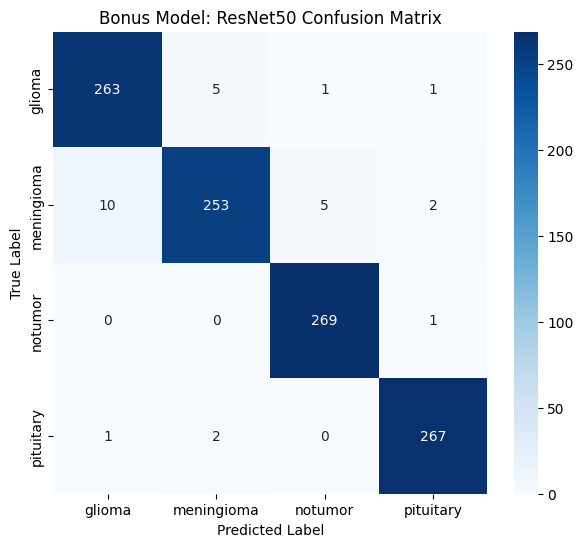

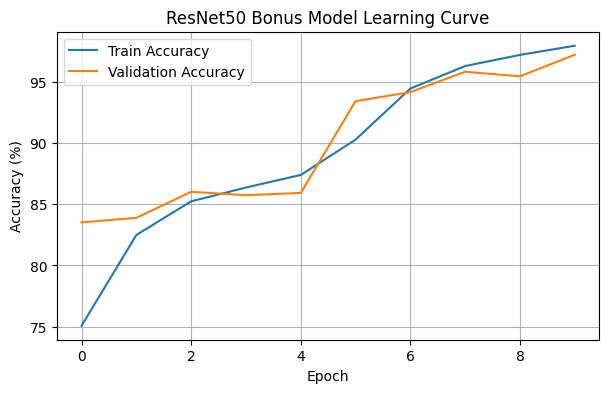


===== BONUS COMPARISON TABLE =====


,Model,Accuracy,Precision,Recall,F1-score
0,EfficientNet-B0 Main Model,0.971300,0.971300,0.971300,0.971200
1,ResNet50 Bonus Extra CNN,0.974074,0.974088,0.974074,0.973961


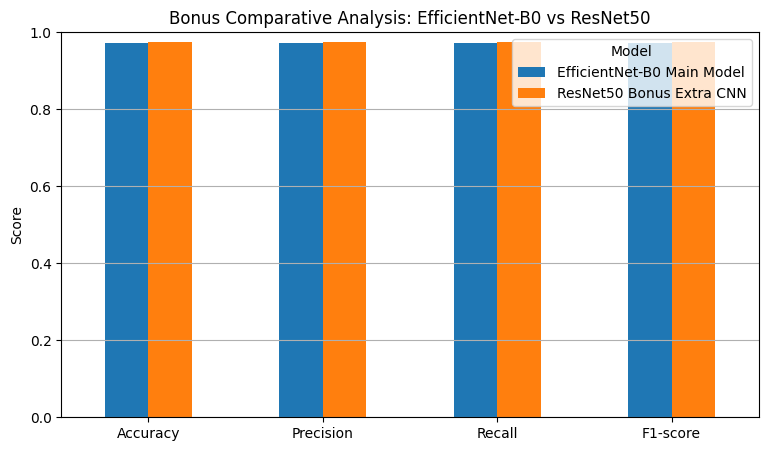

In [26]:
# ============================================================
# BONUS (+1 Mark): Extra CNN Model - ResNet50 End-to-End
# Dataset: /content/drive/MyDrive/datasets/brain-tumor-mri
# Compare ResNet50 with EfficientNet-B0
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# Settings
# =========================
DATASET_DIR = "/content/drive/MyDrive/datasets/brain-tumor-mri"

train_path = os.path.join(DATASET_DIR, "train")
val_path   = os.path.join(DATASET_DIR, "val")
test_path  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4

STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 5

BEST_RESNET_PATH = "/content/drive/MyDrive/datasets/best_resnet50_bonus_brain_tumor.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Transforms
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# Datasets and Loaders
# =========================
train_dataset = ImageFolder(train_path, transform=train_transforms)
val_dataset   = ImageFolder(val_path, transform=eval_transforms)
test_dataset  = ImageFolder(test_path, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

# =========================
# Build ResNet50
# =========================
weights = ResNet50_Weights.DEFAULT
resnet_model = resnet50(weights=weights)

# Replace final classifier
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, NUM_CLASSES)

resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()

# =========================
# Train / Validate Functions
# =========================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total = 0
    correct = 0
    loss_sum = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    avg_loss = loss_sum / len(loader)
    acc = 100 * correct / total

    return avg_loss, acc


def validate(model, loader):
    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = outputs.max(1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    return 100 * correct / total


# =========================
# Stage 1: Train FC only
# =========================
print("\n================ BONUS STAGE 1: Train ResNet50 classifier only ================")

for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    resnet_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0

for epoch in range(STAGE1_EPOCHS):
    train_loss, train_acc = train_one_epoch(resnet_model, train_loader, optimizer, criterion)
    val_acc = validate(resnet_model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"\nStage 1 Epoch {epoch+1}/{STAGE1_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet_model.state_dict(), BEST_RESNET_PATH)
        print("✅ Best ResNet50 Saved")


# =========================
# Stage 2: Fine-tune layer4 + FC
# =========================
print("\n================ BONUS STAGE 2: Fine-tune ResNet50 layer4 + classifier ================")

for param in resnet_model.layer4.parameters():
    param.requires_grad = True

for param in resnet_model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {"params": resnet_model.layer4.parameters(), "lr": 1e-4},
    {"params": resnet_model.fc.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

for epoch in range(STAGE2_EPOCHS):
    train_loss, train_acc = train_one_epoch(resnet_model, train_loader, optimizer, criterion)
    val_acc = validate(resnet_model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"\nStage 2 Epoch {epoch+1}/{STAGE2_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Acc   : {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet_model.state_dict(), BEST_RESNET_PATH)
        print("✅ Best ResNet50 Saved")

print("\nBest ResNet50 Validation Accuracy:", best_val_acc)
print("Best ResNet50 path:", BEST_RESNET_PATH)

# =========================
# Load Best ResNet50
# =========================
try:
    state_dict = torch.load(BEST_RESNET_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(BEST_RESNET_PATH, map_location=device)

resnet_model.load_state_dict(state_dict)
resnet_model = resnet_model.to(device)
resnet_model.eval()

print("\n✅ Best ResNet50 loaded")

# =========================
# Test Evaluation
# =========================
def evaluate_model(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = evaluate_model(resnet_model, test_loader)

resnet_acc = accuracy_score(y_true, y_pred)
resnet_precision = precision_score(y_true, y_pred, average="weighted")
resnet_recall = recall_score(y_true, y_pred, average="weighted")
resnet_f1 = f1_score(y_true, y_pred, average="weighted")

print("\n===== BONUS RESNET50 FINAL TEST RESULTS =====")
print(f"Accuracy  : {resnet_acc:.4f}")
print(f"Precision : {resnet_precision:.4f}")
print(f"Recall    : {resnet_recall:.4f}")
print(f"F1 Score  : {resnet_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Bonus Model: ResNet50 Confusion Matrix")
plt.show()

# =========================
# Learning Curves
# =========================
plt.figure(figsize=(7, 4))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("ResNet50 Bonus Model Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Comparison with your EfficientNet-B0 result
# =========================
efficientnet_acc = 0.9713
efficientnet_precision = 0.9713
efficientnet_recall = 0.9713
efficientnet_f1 = 0.9712

bonus_comparison = pd.DataFrame({
    "Model": [
        "EfficientNet-B0 Main Model",
        "ResNet50 Bonus Extra CNN"
    ],
    "Accuracy": [
        efficientnet_acc,
        resnet_acc
    ],
    "Precision": [
        efficientnet_precision,
        resnet_precision
    ],
    "Recall": [
        efficientnet_recall,
        resnet_recall
    ],
    "F1-score": [
        efficientnet_f1,
        resnet_f1
    ]
})

print("\n===== BONUS COMPARISON TABLE =====")
display(bonus_comparison)

# Bar chart comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

bonus_comparison_plot = bonus_comparison.set_index("Model")[metrics]

bonus_comparison_plot.T.plot(kind="bar", figsize=(9, 5))
plt.title("Bonus Comparative Analysis: EfficientNet-B0 vs ResNet50")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()